# Day 9 - 反向传播 - 网络怎么学的

> 目标: 手写反向传播, 理解梯度怎么从输出层一路传回输入层
>
> 核心: 链式法则 - 就是你高数下考 95 那个

---

## Day 8 vs Day 9

```
Day 8 (前向传播):  x -> W1 -> h -> W2 -> y_pred   (算预测)
Day 9 (反向传播):  loss -> dL/dW2 -> dL/dh -> dL/dW1   (算梯度)
```

前向 = 从输入到输出, 一步步算
反向 = 从损失往回走, 用链式法则算出每个参数的梯度

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
print('=' * 40)
print('Day 9 - Backpropagation')
print('=' * 40)

Day 9 - Backpropagation


## 1. 链式法则复习 - 高数下的老熟人

> 反向传播 = 链式法则在神经网络上的应用, 没有新数学

```
如果 L = f(y), y = g(x)
那么 dL/dx = dL/dy * dy/dx    <- 这就是链式法则

神经网络里:
  L = loss(y_pred, y_true)          损失函数
  y_pred = sigmoid(z2)              输出层激活
  z2 = W2 @ h + b2                  输出层线性
  h = relu(z1)                      隐藏层激活
  z1 = W1 @ x + b1                  隐藏层线性

想求 dL/dW1? 一路链式传回去:
  dL/dW1 = dL/dy_pred * dy_pred/dz2 * dz2/dh * dh/dz1 * dz1/dW1
```

In [11]:
# 直观感受链式法则: y = (3x) 的平方, 在 x=2 处求导

def forward(x):
    a = 3 * x          # a = 3x
    b = a ** 2         # b = a 的平方
    return a, b

def backward(x):
    a, b = forward(x)
    db_da = 2 * a      # dy/da = 2a
    da_dx = 3           # da/dx = 3
    db_dx = db_da * da_dx  # 链式法则
    return db_dx

x = 2.0
a, b = forward(x)
db_dx = backward(x)
true_grad = 18 * x  # 解析解: d/dx (3x)**2 = 18x

print(f'x = {x}')
print(f'a = 3*x = {a}')
print(f'b = a**2 = {b}')
print(f'db/da = 2a = {2*a}')
print(f'da/dx = 3')
print(f'链式法则 db/dx = {db_dx}')
print(f'解析解 dy/dx = 18x = {true_grad}')
print(f'一致！链式法则就是把复杂导数拆成每一步导数的乘积')

x = 2.0
a = 3*x = 6.0
b = a**2 = 36.0
db/da = 2a = 12.0
da/dx = 3
链式法则 db/dx = 36.0
解析解 dy/dx = 18x = 36.0
一致！链式法则就是把复杂导数拆成每一步导数的乘积


## 2. 两层 MLP 完整反向传播推导

```
前向:
  z1 = X @ W1.T + b1          # (m, 3) 隐藏层线性
  h = ReLU(z1)                 # (m, 3) 激活
  z2 = h @ W2.T + b2           # (m, 1) 输出层线性
  y_pred = Sigmoid(z2)         # (m, 1) 概率

损失:
  L = -mean(y*log(y_pred) + (1-y)*log(1-y_pred))

反向 (从后往前, 链式法则):
  dL/dz2    = y_pred - y            # 交叉熵+Sigmoid 简化
  dL/dW2    = (dL/dz2.T @ h) / m    # 输出层权重梯度
  dL/db2    = dL/dz2.mean(0)        # 输出层偏置梯度
  dL/dh     = dL/dz2 @ W2            # 梯度穿过 W2
  dL/dz1    = dL/dh * ReLU'(z1)     # 乘 ReLU 导数
  dL/dW1    = (dL/dz1.T @ X) / m    # 隐藏层权重梯度
  dL/db1    = dL/dz1.mean(0)        # 隐藏层偏置梯度

更新:
  W = W - lr * dW
```

In [12]:
# ============================================
# 手写两层神经网络完整训练 (前向 + 反向 + 更新)
# ============================================

import numpy as np

# ============================================
# 1. 定义激活函数及其导数
# ============================================
def sigmoid(z):
    """
    Sigmoid 激活函数：将任意实数映射到 (0, 1) 之间。
    通常用于输出层进行二分类概率预测。
    np.clip 用于防止指数爆炸导致的数值溢出。
    """
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def relu(z):
    """
    ReLU 激活函数：f(x) = max(0, x)。
    用于隐藏层，引入非线性，解决梯度消失问题，加速收敛。
    """
    return np.maximum(0, z)

def relu_derivative(z):
    """
    ReLU 的导数：
    当 z > 0 时，导数为 1；当 z <= 0 时，导数为 0。
    用于反向传播时计算梯度。
    """
    return (z > 0).astype(float)

# ============================================
# 2. 定义损失函数
# ============================================
def binary_cross_entropy(y_pred, y_true):
    """
    二元交叉熵损失 (BCE)：衡量预测概率分布与真实标签的差异。
    eps (1e-15) 是为了防止 log(0) 导致数学错误。
    """
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# ============================================
# 3. 初始化网络参数
# ============================================
np.random.seed(42) # 固定随机种子，保证结果可复现

# W1: 输入层(2个特征) -> 隐藏层(3个神经元)
# 形状: (3, 2)，即 3行2列
W1 = np.random.randn(3, 2) * 0.5
b1 = np.zeros(3)   # 隐藏层偏置

# W2: 隐藏层(3个神经元) -> 输出层(1个神经元)
# 形状: (1, 3)，即 1行3列
W2 = np.random.randn(1, 3) * 0.5
b2 = np.zeros(1)   # 输出层偏置

# ============================================
# 4. 准备数据 (XOR 问题)
# ============================================
# 输入 X: 4个样本，每个样本2个特征 (0或1)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
# 标签 y: XOR 的结果 (相同为0，不同为1)
y = np.array([[0], [1], [1], [0]])

print(f'输入维度: {X.shape}, W1维度: {W1.shape}, W2维度: {W2.shape}')
print("-" * 30)

# ============================================
# 5. 训练循环
# ============================================
lr = 0.5        # 学习率：控制每次参数更新的步长
epochs = 2000   # 迭代次数
losses = []     # 记录每轮的损失值，用于后续画图观察收敛情况

for epoch in range(epochs):
    # ---- A. 前向传播 (Forward Pass) ----
    # 计算隐藏层的加权输入 z1 = X * W1^T + b1
    # 矩阵运算: (4,2) @ (2,3) -> (4,3)
    z1 = X @ W1.T + b1
    
    # 经过 ReLU 激活得到隐藏层输出 h
    h = relu(z1) 
    
    # 计算输出层的加权输入 z2 = h * W2^T + b2
    # 矩阵运算: (4,3) @ (3,1) -> (4,1)
    z2 = h @ W2.T + b2
    
    # 经过 Sigmoid 激活得到最终预测概率 y_pred
    y_pred = sigmoid(z2) 

    # 计算当前损失
    loss = binary_cross_entropy(y_pred, y)
    losses.append(loss)

    # ---- B. 反向传播 (Backward Pass) ----
    # 核心目标：计算损失 L 对每个参数 (W1, b1, W2, b2) 的梯度
    m = X.shape[0] # 样本数量 (4)

    # 1. 输出层梯度
    # 这是一个重要的数学简化结论：
    # d(Loss)/d(z2) = y_pred - y_true (当 Loss=BCE 且 激活=Sigmoid 时)
    dL_dz2 = y_pred - y             # 形状 (4, 1)

    # 2. 计算 W2 和 b2 的梯度
    # dL/dW2 = (dL/dz2)^T * h / m
    dL_dW2 = (dL_dz2.T @ h) / m     # 形状 (1, 3)
    dL_db2 = np.mean(dL_dz2, axis=0)# 形状 (1,)

    # 3. 将误差反向传导回隐藏层
    # dL/dh = dL/dz2 * W2
    dL_dh = dL_dz2 @ W2             # 形状 (4, 3)
    
    # 4. 穿过 ReLU 激活函数 (链式法则：乘以 ReLU 的导数)
    dL_dz1 = dL_dh * relu_derivative(z1) # 形状 (4, 3)

    # 5. 计算 W1 和 b1 的梯度
    dL_dW1 = (dL_dz1.T @ X) / m     # 形状 (3, 2)
    dL_db1 = np.mean(dL_dz1, axis=0)# 形状 (3,)

    # ---- C. 参数更新 (Gradient Descent) ----
    # 沿着梯度的反方向更新参数，以减小损失
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2

# ============================================
# 6. 结果验证
# ============================================
print(f'训练 {epochs} 轮结束, 最终 Loss: {losses[-1]:.6f}')
print()

# 遍历 4 个样本打印预测结果
for i in range(4):
    # 重新进行一次前向传播以获取最终结果
    z1_i = relu(X[i] @ W1.T + b1)
    z2_i = sigmoid(z1_i @ W2.T + b2)
    
    # 格式化输出：显示 输入 -> 真实值 vs 预测值
    # 注意：这里修复了你原代码中的缩进和换行问题
    print(f'  XOR({X[i][0]:.0f}, {X[i][1]:.0f}) = {y[i][0]:.0f}  |  '
          f'预测: {z2_i[0]:.4f}')

输入维度: (4, 2), W1维度: (3, 2), W2维度: (1, 3)
------------------------------
训练 2000 轮结束, 最终 Loss: 0.001583

  XOR(0, 0) = 0  |  预测: 0.0027
  XOR(0, 1) = 1  |  预测: 0.9995
  XOR(1, 0) = 1  |  预测: 0.9995
  XOR(1, 1) = 0  |  预测: 0.0027


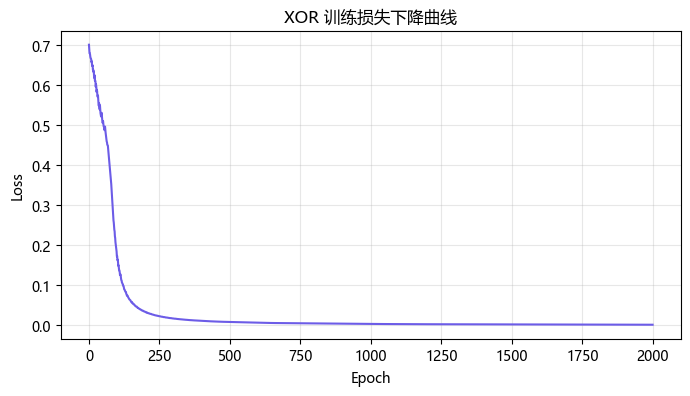

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color='#6c5ce7', linewidth=1.5)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('XOR 训练损失下降曲线')
plt.grid(True, alpha=0.3)
plt.show()

## 3. 梯度检查 - 验证反向传播

> 数值梯度 (定义法) vs 解析梯度 (反向传播)

```
数值梯度:  df/dx ~ (f(x+eps) - f(x-eps)) / (2*eps)   慢但正确
解析梯度:  df/dx = 反向传播算出来的                      快但可能写错
差距 < 1e-5 -> 反向传播写对了
```

In [18]:
# 梯度检查: 数值梯度 vs 反向传播梯度

import numpy as np

# ==========================================
# 1. 基础组件 (激活函数与损失函数)
# ==========================================

def relu(z):
    """ReLU 激活函数: max(0, z)"""
    return np.maximum(0, z)

def relu_derivative(z):
    """ReLU 的导数: z>0 为 1, 否则为 0"""
    return (z > 0).astype(float)

def sigmoid(z):
    """Sigmoid 激活函数: 将输出映射到 (0, 1)"""
    # clip 防止指数爆炸
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def binary_cross_entropy(y_pred, y_true):
    """二元交叉熵损失函数 (BCE)"""
    eps = 1e-15  # 防止 log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def loss_gradient(y_pred, y_true):
    """
    BCE Loss + Sigmoid 组合的梯度简化形式
    dL/dz2 = y_pred - y_true
    """
    return y_pred - y_true

# ==========================================
# 2. 神经网络核心逻辑
# ==========================================

def forward_pass(X, W1, b1, W2, b2):
    """
    前向传播：计算预测值
    流程: Input -> Linear -> ReLU -> Linear -> Sigmoid -> Output
    """
    z1 = X @ W1.T + b1          # 第一层线性变换
    h = relu(z1)                # 第一层激活 (隐藏层输出)
    z2 = h @ W2.T + b2          # 第二层线性变换
    y_pred = sigmoid(z2)        # 第二层激活 (最终预测概率)
    
    # 返回中间变量，供反向传播使用
    return z1, h, z2, y_pred

def backward_pass(X, y, z1, h, z2, y_pred, W1, W2):
    """
    反向传播：利用链式法则计算梯度
    这是我们要验证的核心算法 (解析解)
    """
    m = X.shape[0]  # 样本数量

    # --- 输出层梯度 ---
    dL_dz2 = loss_gradient(y_pred, y)           # (m, 1)
    dL_dW2 = (dL_dz2.T @ h) / m                 # (1, hidden_size)
    dL_db2 = dL_dz2.mean(axis=0)                  # (1,)

    # --- 隐藏层梯度 ---
    dL_dh = dL_dz2 @ W2                           # (m, hidden_size) 梯度回传
    dL_dz1 = dL_dh * relu_derivative(z1)          # (m, hidden_size) 穿过 ReLU
    dL_dW1 = (dL_dz1.T @ X) / m                   # (hidden_size, input_size)
    dL_db1 = dL_dz1.mean(axis=0)                    # (hidden_size,)

    return dL_dW1, dL_db1, dL_dW2, dL_db2

# ==========================================
# 3. 数值梯度计算 (用于验证的"标准答案")
# ==========================================

def numerical_gradient(param, X, y, W1, b1, W2, b2, eps=1e-5):
    """
    使用定义法计算梯度 (数值解)
    公式: f'(x) ≈ (f(x+eps) - f(x-eps)) / (2*eps)
    这种方法虽然慢，但几乎不会写错，常用来检验反向传播代码。
    """
    grad = np.zeros_like(param) # 初始化一个形状相同的零矩阵
    
    # 使用 nditer 遍历参数矩阵中的每一个元素
    it = np.nditer(param, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index    # 获取当前元素的索引 (例如 [0, 1])
        old_val = param[idx]    # 保存原始值
        
        # 1. 计算 f(x + eps)
        param[idx] = old_val + eps
        _, _, _, yp_plus = forward_pass(X, W1, b1, W2, b2)
        loss_plus = binary_cross_entropy(yp_plus, y)
        
        # 2. 计算 f(x - eps)
        param[idx] = old_val - eps
        _, _, _, yp_minus = forward_pass(X, W1, b1, W2, b2)
        loss_minus = binary_cross_entropy(yp_minus, y)
        
        # 3. 恢复原始值 (非常重要！避免修改了原网络参数)
        param[idx] = old_val
        
        # 4. 计算该维度的梯度
        grad[idx] = (loss_plus - loss_minus) / (2 * eps)
        
        it.iternext() # 移动到下一个元素
        
    return grad

# ==========================================
# 4. 执行梯度检查
# ==========================================

print("--- 开始梯度检查 ---")

# 设置随机种子保证结果可复现
np.random.seed(123)

# 初始化一个小网络: 输入2维 -> 隐藏2维 -> 输出1维
W1_t = np.random.randn(2, 2) * 0.1
b1_t = np.zeros(2)
W2_t = np.random.randn(1, 2) * 0.1
b2_t = np.zeros(1)

# 构造测试数据
X_t = np.array([[0.5, -0.3]]) # 1个样本，2个特征
y_t = np.array([[1]])         # 真实标签

# 1. 先跑一次前向传播，拿到中间状态
z1_t, h_t, z2_t, yp_t = forward_pass(X_t, W1_t, b1_t, W2_t, b2_t)

# 2. 用【反向传播公式】算梯度 (解析解)
dW1_analytic, _, _, _ = backward_pass(X_t, y_t, z1_t, h_t, z2_t, yp_t, W1_t, W2_t)

# 3. 用【数值微分】算梯度 (数值解)
# 注意：这里传入 W1_t 作为第一个参数，表示我们要检查 W1 的梯度
dW1_numeric = numerical_gradient(W1_t, X_t, y_t, W1_t, b1_t, W2_t, b2_t)

# 4. 打印对比结果
print('反向传播梯度 (Analytic):')
print(f'  {np.round(dW1_analytic, 8)}')

print('数值梯度 (Numeric):')
print(f'  {np.round(dW1_numeric, 8)}')

# 5. 计算最大绝对误差
diff = np.max(np.abs(dW1_analytic - dW1_numeric))
print(f'\n最大差值: {diff:.2e}')

# 6. 判定结果
# 通常误差小于 1e-5 或 1e-7 就认为反向传播实现正确
if diff < 1e-5:
    print('✅ 梯度检查通过! 代码逻辑正确。')
else:
    print('❌ 有偏差! 请检查反向传播公式或数值计算的 eps。')

--- 开始梯度检查 ---
反向传播梯度 (Analytic):
  [[ 0.          0.        ]
 [-0.04108363  0.02465018]]
数值梯度 (Numeric):
  [[ 0.          0.        ]
 [-0.04108363  0.02465018]]

最大差值: 4.55e-12
✅ 梯度检查通过! 代码逻辑正确。


## 4. sklearn MLP vs 手写

| 我们手写的 | sklearn 内部 |
|-----------|-------------|
| forward_pass | _forward_pass() |
| backward_pass | _backward_pass() |
| W -= lr * dW | optimizer.update() |
| 固定 lr=0.5 | learning_rate_init |
| 全量梯度下降 | solver='sgd' |

In [17]:
# sklearn vs 手写对比 (XOR)
X_train, X_test, y_train, y_test = train_test_split(
    X, y.ravel(), test_size=0.5, random_state=42
)

mlp_sk = MLPClassifier(hidden_layer_sizes=(3,), activation='relu',
                       solver='sgd', learning_rate_init=0.5, max_iter=200000, random_state=42)
mlp_sk.fit(X_train, y_train)
sk_pred = mlp_sk.predict(X_test)

def predict(X, W1, b1, W2, b2):
    h = relu(X @ W1.T + b1)
    return (sigmoid(h @ W2.T + b2) > 0.5).astype(int).ravel()

our_pred = predict(X_test, W1, b1, W2, b2)

print('XOR 对比:')
print(f'  sklearn 预测: {sk_pred}')
print(f'  手写预测:     {our_pred}')
print(f'  真实标签:     {y_test.ravel().astype(int)}')
print(f'  sklearn 准确率: {(sk_pred == y_test.ravel()).mean():.7f}')
print(f'  手写准确率:     {(our_pred == y_test.ravel()).mean():.7f}')

XOR 对比:
  sklearn 预测: [0 1]
  手写预测:     [1 0]
  真实标签:     [1 0]
  sklearn 准确率: 0.0000000
  手写准确率:     1.0000000


---

# Day 9 完成！

## 今天手写了什么

| 模块 | 核心代码 | 行数 |
|------|---------|------|
| **前向传播** | h = relu(X @ W1.T + b1) | 4 行 |
| **损失函数** | -mean(y*log(yp) + (1-y)*log(1-yp)) | 3 行 |
| **反向传播** | dL_dz2 = y_pred - y 开始, 一路链式传回 | 6 行 |
| **梯度下降** | W -= lr * dW | 4 行 |
| **梯度检查** | 数值梯度 vs 解析梯度 | 验证 |

## 反向传播 5 行核心

```
dL_dz2  = y_pred - y                      # 输出层梯度 (交叉熵+Sigmoid简化)
dL_dW2  = (dL_dz2.T @ h) / m              # 输出层权重梯度
dL_dh   = dL_dz2 @ W2                      # 梯度穿过 W2
dL_dz1  = dL_dh * ReLU'(z1)                # 乘激活函数导数
dL_dW1  = (dL_dz1.T @ X) / m              # 隐藏层权重梯度
```

## 晚上作业

1. 把 hidden_dim 从 3 改成 10, loss 降得更快吗?
2. 把 ReLU 改成 Sigmoid, 观察梯度变化
3. 预习 Day 10: PyTorch 入门 - 同样的反向传播, PyTorch 自动帮你算